# 01 — Model Development and Threshold Governance

This notebook builds the technical baseline for a Responsible AI review of a credit risk decision-support model.

The objective is not to win a modelling benchmark. The objective is to produce evidence that can be used in governance artefacts: model card, testing summary, risk-control matrix, and later fairness assessment.

**Use case framing**

A simulated European financial institution wants to assess whether a credit risk model could support loan application review. The model produces a risk score for “bad credit risk”. It is treated as a decision-support tool, not as a fully automated approval or rejection system.

**What this notebook covers**

1. Load and inspect the German Credit Dataset.
2. Define the target and subgroup attributes needed for later fairness testing.
3. Train simple baseline models.
4. Select a candidate model using a validation set.
5. Calibrate probabilities.
6. Select a cost-sensitive threshold on the validation set.
7. Evaluate the final candidate model on a held-out test set.
8. Save metrics, plots and tables for the repository.
9. Produce concise results to copy into governance artefacts.

**Important validation design**

The threshold is selected on the validation set, not on the test set. The final reported metrics are produced on a separate held-out test set.

## 1. Setup

The notebook uses standard Python and scikit-learn tooling so that it remains easy to run in Google Colab and easy to review.

In [ ]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

## 2. Load the German Credit Dataset

The dataset is loaded from OpenML.

The target is converted to:

- `1` = bad credit risk;
- `0` = good credit risk.

This direction is important because the thresholding logic later treats the positive class as the risk class.

In [ ]:
def load_german_credit_from_openml():
    data = fetch_openml(name="credit-g", version=1, as_frame=True)
    df = data.frame.copy()

    if "class" not in df.columns:
        raise ValueError("Expected target column 'class' was not found.")

    return df


df = load_german_credit_from_openml()

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (1000, 21)


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,4,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,4,no known property,53,none,for free,2,skilled,2,none,yes,bad


In [ ]:
target_col = "class"

print("Raw target distribution:")
display(df[target_col].value_counts(dropna=False))

df["bad_risk"] = df[target_col].astype(str).str.lower().map({"bad": 1, "good": 0})

if df["bad_risk"].isna().any():
    raise ValueError("Target conversion failed. Check target labels.")

print("\nConverted target distribution:")
display(df["bad_risk"].value_counts(normalize=True).rename("share").to_frame())

Raw target distribution:


,count
class,
good,700
bad,300



Converted target distribution:


,share
bad_risk,
0,0.7
1,0.3


## 3. Basic Data Review

This section is intentionally short. The goal is to understand the dataset well enough to support model development and governance documentation, not to perform a full exploratory analysis.

In [ ]:
overview = pd.DataFrame({
    "n_rows": [df.shape[0]],
    "n_columns": [df.shape[1]],
    "n_missing_values": [int(df.isna().sum().sum())],
    "bad_risk_rate": [df["bad_risk"].mean()]
})

display(overview)

missing_values = (
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)

display(missing_values.head(10))

,n_rows,n_columns,n_missing_values,bad_risk_rate
0,1000,22,0,0.3


,missing_count
checking_status,0
duration,0
credit_history,0
purpose,0
credit_amount,0
savings_status,0
employment,0
installment_commitment,0
personal_status,0
other_parties,0


In [ ]:
excluded_cols = [target_col, "bad_risk"]
feature_cols = [c for c in df.columns if c not in excluded_cols]

categorical_cols = [
    c for c in feature_cols
    if str(df[c].dtype) in ["category", "object", "string"]
]

numeric_cols = [
    c for c in feature_cols
    if c not in categorical_cols
]

print(f"Number of features: {len(feature_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Numeric features: {len(numeric_cols)}")

display(pd.DataFrame({
    "column": feature_cols,
    "dtype": [str(df[c].dtype) for c in feature_cols],
    "n_unique": [df[c].nunique(dropna=False) for c in feature_cols]
}))

Number of features: 20
Categorical features: 13
Numeric features: 7


,column,dtype,n_unique
0,checking_status,category,4
1,duration,int64,33
2,credit_history,category,5
3,purpose,category,10
4,credit_amount,int64,921
5,savings_status,category,5
6,employment,category,5
7,installment_commitment,int64,4
8,personal_status,category,4
9,other_parties,category,3


## 4. Subgroup Attributes for Later Responsible AI Testing

This notebook derives subgroup attributes that will be reused in Notebook 02.

The model is trained on the original feature set. The subgroup variables below are primarily used for testing and governance review.

Subgroups used in this project:

- gender, derived from `personal_status`;
- age group, derived from `age`;
- foreign worker status, from `foreign_worker`.

These attributes are imperfect and dataset-specific. They are used here for Responsible AI testing in a portfolio case study, not as a complete legal discrimination assessment.

In [ ]:
def derive_gender_from_personal_status(value):
    value = str(value).lower()
    if value.startswith("male"):
        return "male"
    if value.startswith("female"):
        return "female"
    return "unknown"


def derive_age_group(age):
    age = float(age)
    if age <= 27:
        return "18-27"
    elif age <= 37:
        return "28-37"
    elif age <= 47:
        return "38-47"
    else:
        return "48+"


df["gender_group"] = df["personal_status"].apply(derive_gender_from_personal_status)
df["age_group"] = df["age"].apply(derive_age_group)

if "foreign_worker" in df.columns:
    df["foreign_worker_group"] = df["foreign_worker"].astype(str)
else:
    df["foreign_worker_group"] = "not_available"

for col in ["gender_group", "age_group", "foreign_worker_group"]:
    print(f"\nSubgroup summary: {col}")
    display(
        df.groupby(col)
        .agg(
            n=("bad_risk", "size"),
            bad_risk_rate=("bad_risk", "mean")
        )
        .sort_values("n", ascending=False)
    )


Subgroup summary: gender_group


,n,bad_risk_rate
gender_group,,
male,690,0.276812
female,310,0.351613



Subgroup summary: age_group


,n,bad_risk_rate
age_group,,
28-37,365,0.287671
18-27,291,0.367698
38-47,193,0.259067
48+,151,0.251656



Subgroup summary: foreign_worker_group


,n,bad_risk_rate
foreign_worker_group,,
yes,963,0.307373
no,37,0.108108


## 5. Train / Validation / Test Split

The dataset is split into:

- training set: model fitting;
- validation set: model comparison and threshold selection;
- test set: final held-out evaluation.

This matters for governance credibility. The final test set should not be used to choose the operating threshold.

In [ ]:
X = df[feature_cols].copy()
y = df["bad_risk"].copy()
subgroups = df[["gender_group", "age_group", "foreign_worker_group"]].copy()

X_train_val, X_test, y_train_val, y_test, subgroups_train_val, subgroups_test = train_test_split(
    X,
    y,
    subgroups,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val, subgroups_train, subgroups_val = train_test_split(
    X_train_val,
    y_train_val,
    subgroups_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "bad_risk_rate": [y_train.mean(), y_val.mean(), y_test.mean()]
})

display(split_summary)
split_summary.to_csv(TABLES_DIR / "split_summary.csv", index=False)

,split,rows,bad_risk_rate
0,train,600,0.3
1,validation,200,0.3
2,test,200,0.3


## 6. Preprocessing and Candidate Models

The model search is deliberately small.

We test:

1. logistic regression variants;
2. random forest variants;
3. a small histogram gradient boosting benchmark.

The point is to check whether a more flexible model materially improves performance. If the performance difference is small, the simpler model remains preferable for governance and explainability reasons.

In [ ]:
try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", encoder, categorical_cols),
    ],
    remainder="drop"
)

candidate_models = {
    "logistic_regression_C0_3": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, C=0.3, random_state=RANDOM_STATE))
    ]),
    "logistic_regression_C1": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE))
    ]),
    "logistic_regression_C3": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, C=3.0, random_state=RANDOM_STATE))
    ]),
    "random_forest_depth4": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=10,
            random_state=RANDOM_STATE
        ))
    ]),
    "random_forest_depth6": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=8,
            random_state=RANDOM_STATE
        ))
    ]),
    "hist_gradient_boosting": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", HistGradientBoostingClassifier(
            max_iter=100,
            learning_rate=0.05,
            max_leaf_nodes=15,
            l2_regularization=0.1,
            random_state=RANDOM_STATE
        ))
    ]),
}

In [ ]:
def evaluate_probabilistic_classifier(model, X_eval, y_eval, threshold=0.50):
    y_score = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_eval, y_pred).ravel()

    return {
        "roc_auc": roc_auc_score(y_eval, y_score),
        "average_precision": average_precision_score(y_eval, y_score),
        "brier_score": brier_score_loss(y_eval, y_score),
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_bad_risk": precision_score(y_eval, y_pred, zero_division=0),
        "recall_bad_risk": recall_score(y_eval, y_pred, zero_division=0),
        "f1_bad_risk": f1_score(y_eval, y_pred, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "high_risk_flag_rate": y_pred.mean()
    }


validation_results = []

for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    metrics = evaluate_probabilistic_classifier(model, X_val, y_val, threshold=0.50)
    metrics["model"] = model_name
    validation_results.append(metrics)

validation_results_df = (
    pd.DataFrame(validation_results)
    .set_index("model")
    .sort_values("roc_auc", ascending=False)
)

display(validation_results_df.round(4))
validation_results_df.to_csv(TABLES_DIR / "model_comparison_validation.csv")

,roc_auc,average_precision,brier_score,accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,true_negatives,false_positives,false_negatives,true_positives,high_risk_flag_rate
model,,,,,,,,,,,,
hist_gradient_boosting,0.7425,0.5407,0.1897,0.690,0.4792,0.3833,0.4259,115,25,37,23,0.240
random_forest_depth6,0.7369,0.5075,0.1822,0.705,0.5333,0.1333,0.2133,133,7,52,8,0.075
logistic_regression_C1,0.7264,0.5637,0.1959,0.695,0.4906,0.4333,0.4602,113,27,34,26,0.265
random_forest_depth4,0.7249,0.4898,0.1864,0.710,0.6250,0.0833,0.1471,137,3,55,5,0.040
logistic_regression_C3,0.7248,0.5587,0.1997,0.685,0.4727,0.4333,0.4522,111,29,34,26,0.275
logistic_regression_C0_3,0.7244,0.5496,0.1909,0.690,0.4800,0.4000,0.4364,114,26,36,24,0.250


## 7. Candidate Model Selection

The primary selection metric is validation ROC AUC, because it measures ranking performance independent of a specific threshold.

However, model selection is not only a leaderboard exercise. For this use case, a simpler model may be preferable if performance is comparable, because it is easier to explain, challenge and monitor.

Decision rule used here:

- select the best validation ROC AUC model by default;
- if a logistic regression model is within 0.02 ROC AUC of the best model, select the best logistic regression model for interpretability.

In [ ]:
best_auc = validation_results_df["roc_auc"].max()
best_auc_model_name = validation_results_df["roc_auc"].idxmax()

logistic_candidates = validation_results_df[
    validation_results_df.index.str.startswith("logistic_regression")
]

best_logistic_name = logistic_candidates["roc_auc"].idxmax()
best_logistic_auc = logistic_candidates.loc[best_logistic_name, "roc_auc"]

if best_auc - best_logistic_auc <= 0.02:
    selected_model_name = best_logistic_name
    selection_reason = "Selected logistic regression because it was within 0.02 ROC AUC of the best validation model and is easier to explain."
else:
    selected_model_name = best_auc_model_name
    selection_reason = "Selected best validation ROC AUC model."

selected_base_model = candidate_models[selected_model_name]

print(f"Best validation ROC AUC model: {best_auc_model_name} ({best_auc:.3f})")
print(f"Best logistic regression model: {best_logistic_name} ({best_logistic_auc:.3f})")
print(f"Selected candidate model: {selected_model_name}")
print(selection_reason)

Best validation ROC AUC model: hist_gradient_boosting (0.743)
Best logistic regression model: logistic_regression_C1 (0.726)
Selected candidate model: logistic_regression_C1
Selected logistic regression because it was within 0.02 ROC AUC of the best validation model and is easier to explain.


## 8. Probability Calibration

Calibration matters because the model output is interpreted as a risk score.

A model can rank applicants well while still producing probabilities that are too high or too low. In a credit context, poor calibration can weaken threshold decisions, monitoring and human review.

The selected base model is calibrated using sigmoid calibration on the training set. The validation set remains available for threshold selection.

In [ ]:
calibrated_model = CalibratedClassifierCV(
    estimator=selected_base_model,
    method="sigmoid",
    cv=3
)

calibrated_model.fit(X_train, y_train)

base_val_metrics = evaluate_probabilistic_classifier(selected_base_model, X_val, y_val, threshold=0.50)
calibrated_val_metrics = evaluate_probabilistic_classifier(calibrated_model, X_val, y_val, threshold=0.50)

calibration_comparison = pd.DataFrame([
    {"model_version": "uncalibrated_selected_model", **base_val_metrics},
    {"model_version": "calibrated_sigmoid", **calibrated_val_metrics},
]).set_index("model_version")

display(calibration_comparison[[
    "roc_auc",
    "average_precision",
    "brier_score",
    "accuracy",
    "precision_bad_risk",
    "recall_bad_risk",
    "high_risk_flag_rate"
]].round(4))

calibration_comparison.to_csv(TABLES_DIR / "calibration_comparison_validation.csv")

final_model = calibrated_model
final_model_name = f"{selected_model_name}_calibrated_sigmoid"

,roc_auc,average_precision,brier_score,accuracy,precision_bad_risk,recall_bad_risk,high_risk_flag_rate
model_version,,,,,,,
uncalibrated_selected_model,0.7264,0.5637,0.1959,0.695,0.4906,0.4333,0.265
calibrated_sigmoid,0.7230,0.5546,0.1848,0.715,0.5349,0.3833,0.215


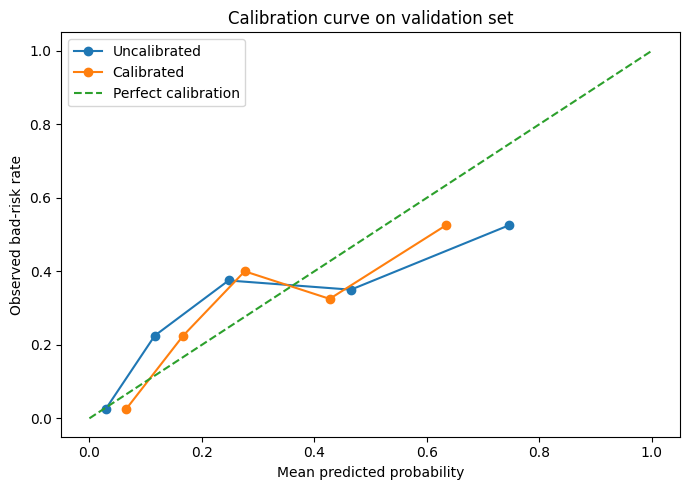

In [ ]:
y_score_val_uncalibrated = selected_base_model.predict_proba(X_val)[:, 1]
y_score_val_calibrated = final_model.predict_proba(X_val)[:, 1]

prob_true_uncal, prob_pred_uncal = calibration_curve(y_val, y_score_val_uncalibrated, n_bins=5, strategy="quantile")
prob_true_cal, prob_pred_cal = calibration_curve(y_val, y_score_val_calibrated, n_bins=5, strategy="quantile")

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_uncal, prob_true_uncal, marker="o", label="Uncalibrated")
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Calibrated")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed bad-risk rate")
plt.title("Calibration curve on validation set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "calibration_curve_validation.png", dpi=150)
plt.show()

## 9. Cost-Sensitive Threshold Selection on Validation Set

The default threshold of 0.50 is rarely a neutral business choice.

For this case study, the positive class is `bad_risk = 1`. We use the classic German Credit asymmetric cost assumption:

- false negative: bad risk classified as good → cost 5;
- false positive: good risk classified as bad → cost 1.

The threshold is selected on the validation set. Final performance is then reported on the held-out test set.

In [ ]:
COST_FALSE_NEGATIVE = 5
COST_FALSE_POSITIVE = 1

def threshold_metrics(y_true, y_score, threshold):
    y_pred = (y_score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    total_cost = (COST_FALSE_NEGATIVE * fn) + (COST_FALSE_POSITIVE * fp)
    avg_cost = total_cost / len(y_true)

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_bad_risk": precision_score(y_true, y_pred, zero_division=0),
        "recall_bad_risk": recall_score(y_true, y_pred, zero_division=0),
        "f1_bad_risk": f1_score(y_true, y_pred, zero_division=0),
        "true_negatives": tn,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "false_positive_rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": fn / (fn + tp) if (fn + tp) > 0 else np.nan,
        "high_risk_flag_rate": y_pred.mean(),
        "total_cost": total_cost,
        "avg_cost_per_applicant": avg_cost
    }


y_score_val = final_model.predict_proba(X_val)[:, 1]
threshold_grid = np.round(np.arange(0.05, 0.96, 0.01), 2)

threshold_results_val = pd.DataFrame([
    threshold_metrics(y_val, y_score_val, threshold)
    for threshold in threshold_grid
])

threshold_results_val["roc_auc"] = roc_auc_score(y_val, y_score_val)
threshold_results_val["average_precision"] = average_precision_score(y_val, y_score_val)
threshold_results_val["brier_score"] = brier_score_loss(y_val, y_score_val)

best_threshold_row = threshold_results_val.loc[threshold_results_val["total_cost"].idxmin()]
selected_threshold = float(best_threshold_row["threshold"])

print(f"Selected cost-sensitive threshold from validation set: {selected_threshold:.2f}")

display(
    threshold_results_val
    .sort_values("total_cost")
    .head(10)
    .round(4)
)

threshold_results_val.to_csv(TABLES_DIR / "threshold_comparison_validation_all.csv", index=False)

Selected cost-sensitive threshold from validation set: 0.16


,threshold,accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate,high_risk_flag_rate,total_cost,avg_cost_per_applicant,roc_auc,average_precision,brier_score
11,0.16,0.555,0.3986,0.9500,0.5616,54,86,3,57,0.6143,0.0500,0.715,101,0.505,0.723,0.5546,0.1848
13,0.18,0.585,0.4135,0.9167,0.5699,62,78,5,55,0.5571,0.0833,0.665,103,0.515,0.723,0.5546,0.1848
7,0.12,0.510,0.3766,0.9667,0.5421,44,96,2,58,0.6857,0.0333,0.770,106,0.530,0.723,0.5546,0.1848
10,0.15,0.530,0.3851,0.9500,0.5481,49,91,3,57,0.6500,0.0500,0.740,106,0.530,0.723,0.5546,0.1848
6,0.11,0.495,0.3694,0.9667,0.5346,41,99,2,58,0.7071,0.0333,0.785,109,0.545,0.723,0.5546,0.1848
9,0.14,0.510,0.3750,0.9500,0.5377,45,95,3,57,0.6786,0.0500,0.760,110,0.550,0.723,0.5546,0.1848
5,0.10,0.470,0.3598,0.9833,0.5268,35,105,1,59,0.7500,0.0167,0.820,110,0.550,0.723,0.5546,0.1848
8,0.13,0.510,0.3750,0.9500,0.5377,45,95,3,57,0.6786,0.0500,0.760,110,0.550,0.723,0.5546,0.1848
12,0.17,0.550,0.3929,0.9167,0.5500,55,85,5,55,0.6071,0.0833,0.700,110,0.550,0.723,0.5546,0.1848
17,0.22,0.610,0.4262,0.8667,0.5714,70,70,8,52,0.5000,0.1333,0.610,110,0.550,0.723,0.5546,0.1848


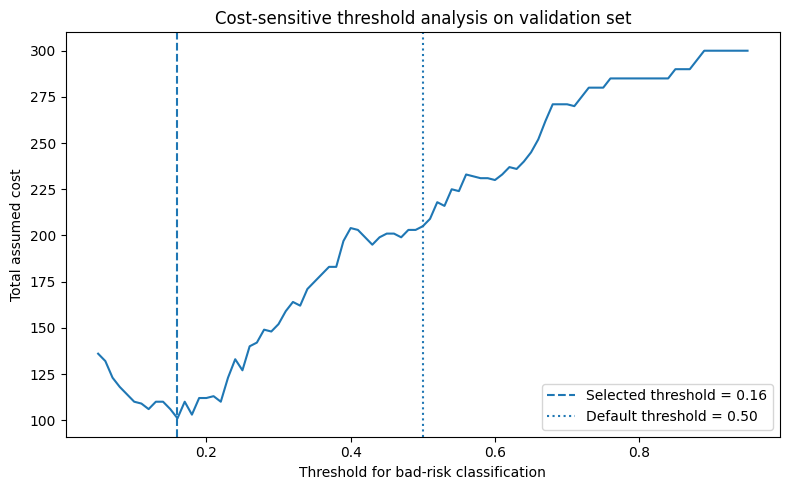

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_results_val["threshold"], threshold_results_val["total_cost"])
plt.axvline(selected_threshold, linestyle="--", label=f"Selected threshold = {selected_threshold:.2f}")
plt.axvline(0.50, linestyle=":", label="Default threshold = 0.50")
plt.xlabel("Threshold for bad-risk classification")
plt.ylabel("Total assumed cost")
plt.title("Cost-sensitive threshold analysis on validation set")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "cost_sensitive_threshold_curve_validation.png", dpi=150)
plt.show()

## 10. Final Evaluation on Held-Out Test Set

The model and threshold have now been selected. This section evaluates the final candidate on the held-out test set.

This is the performance evidence that should be used in the model card and testing summary.

In [ ]:
y_score_test = final_model.predict_proba(X_test)[:, 1]

test_metrics_default = threshold_metrics(y_test, y_score_test, 0.50)
test_metrics_selected = threshold_metrics(y_test, y_score_test, selected_threshold)

test_summary = pd.DataFrame([
    {"threshold_basis": "default_0_50", **test_metrics_default},
    {"threshold_basis": "cost_sensitive_selected_on_validation", **test_metrics_selected}
])

test_summary["model"] = final_model_name
test_summary["roc_auc"] = roc_auc_score(y_test, y_score_test)
test_summary["average_precision"] = average_precision_score(y_test, y_score_test)
test_summary["brier_score"] = brier_score_loss(y_test, y_score_test)

display(test_summary.round(4))
test_summary.to_csv(TABLES_DIR / "governance_model_summary_test.csv", index=False)

,threshold_basis,threshold,accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,true_negatives,false_positives,false_negatives,true_positives,false_positive_rate,false_negative_rate,high_risk_flag_rate,total_cost,avg_cost_per_applicant,model,roc_auc,average_precision,brier_score
0,default_0_50,0.50,0.750,0.6190,0.4333,0.5098,124,16,34,26,0.1143,0.5667,0.210,186,0.930,logistic_regression_C1_calibrated_sigmoid,0.7795,0.6122,0.1645
1,cost_sensitive_selected_on_validation,0.16,0.515,0.3706,0.8833,0.5222,50,90,7,53,0.6429,0.1167,0.715,125,0.625,logistic_regression_C1_calibrated_sigmoid,0.7795,0.6122,0.1645


In [ ]:
comparison_thresholds = sorted(set([
    0.50,
    selected_threshold,
    0.20,
    0.30,
    0.40
]))

threshold_comparison_test = pd.DataFrame([
    threshold_metrics(y_test, y_score_test, threshold)
    for threshold in comparison_thresholds
])

threshold_comparison_test["roc_auc"] = roc_auc_score(y_test, y_score_test)
threshold_comparison_test["average_precision"] = average_precision_score(y_test, y_score_test)
threshold_comparison_test["brier_score"] = brier_score_loss(y_test, y_score_test)

cols = [
    "threshold",
    "roc_auc",
    "average_precision",
    "brier_score",
    "accuracy",
    "precision_bad_risk",
    "recall_bad_risk",
    "f1_bad_risk",
    "false_positives",
    "false_negatives",
    "false_positive_rate",
    "false_negative_rate",
    "high_risk_flag_rate",
    "total_cost",
    "avg_cost_per_applicant"
]

display(threshold_comparison_test[cols].sort_values("threshold").round(4))

threshold_comparison_test[cols].sort_values("threshold").to_csv(
    TABLES_DIR / "threshold_comparison_test_selected.csv",
    index=False
)

,threshold,roc_auc,average_precision,brier_score,accuracy,precision_bad_risk,recall_bad_risk,f1_bad_risk,false_positives,false_negatives,false_positive_rate,false_negative_rate,high_risk_flag_rate,total_cost,avg_cost_per_applicant
0,0.16,0.7795,0.6122,0.1645,0.515,0.3706,0.8833,0.5222,90,7,0.6429,0.1167,0.715,125,0.625
1,0.20,0.7795,0.6122,0.1645,0.625,0.4380,0.8833,0.5856,68,7,0.4857,0.1167,0.605,103,0.515
2,0.30,0.7795,0.6122,0.1645,0.700,0.5000,0.7833,0.6104,47,13,0.3357,0.2167,0.470,112,0.560
3,0.40,0.7795,0.6122,0.1645,0.770,0.6029,0.6833,0.6406,27,19,0.1929,0.3167,0.340,122,0.610
4,0.50,0.7795,0.6122,0.1645,0.750,0.6190,0.4333,0.5098,16,34,0.1143,0.5667,0.210,186,0.930


In [ ]:
test_predictions = subgroups_test.reset_index(drop=True).copy()
test_predictions["y_true_bad_risk"] = y_test.reset_index(drop=True).astype(int)
test_predictions["y_score_bad_risk"] = y_score_test
test_predictions["y_pred_bad_risk_default_050"] = (y_score_test >= 0.50).astype(int)
test_predictions["y_pred_bad_risk_selected_threshold"] = (y_score_test >= selected_threshold).astype(int)

test_predictions.to_csv(TABLES_DIR / "test_predictions_for_fairness.csv", index=False)

display(test_predictions.head())

,gender_group,age_group,foreign_worker_group,y_true_bad_risk,y_score_bad_risk,y_pred_bad_risk_default_050,y_pred_bad_risk_selected_threshold
0,male,28-37,yes,0,0.323267,0,1
1,male,28-37,yes,0,0.115764,0,0
2,male,48+,yes,1,0.557767,1,1
3,male,28-37,yes,0,0.488732,0,1
4,male,18-27,yes,1,0.204971,0,1


## 11. Confusion Matrices

The confusion matrices below compare the default threshold with the selected cost-sensitive threshold on the test set.

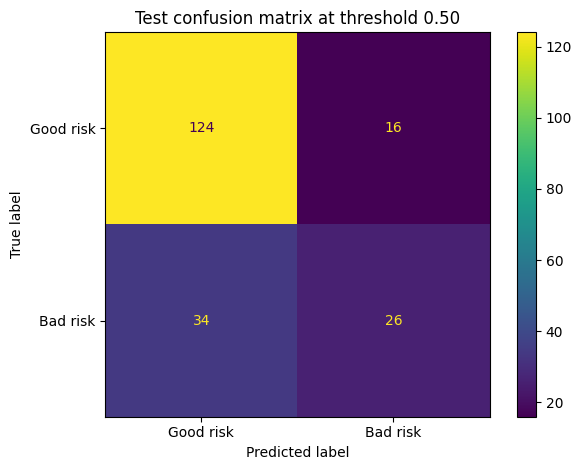

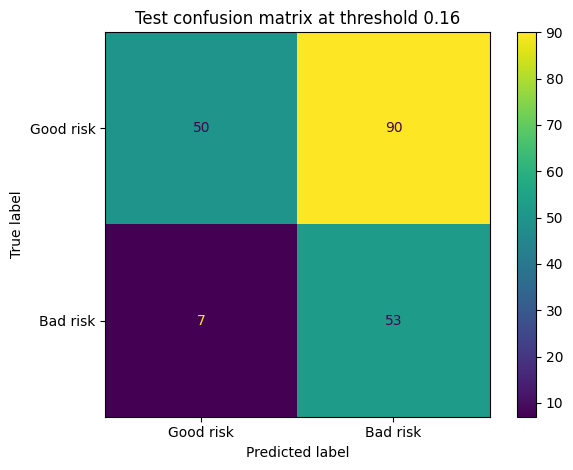

In [ ]:
def plot_confusion_matrix_at_threshold(y_true, y_score, threshold, filename):
    y_pred = (y_score >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Good risk", "Bad risk"]
    )
    disp.plot(values_format="d")
    plt.title(f"Test confusion matrix at threshold {threshold:.2f}")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=150)
    plt.show()


plot_confusion_matrix_at_threshold(
    y_test,
    y_score_test,
    0.50,
    "confusion_matrix_test_threshold_050.png"
)

plot_confusion_matrix_at_threshold(
    y_test,
    y_score_test,
    selected_threshold,
    "confusion_matrix_test_selected_threshold.png"
)

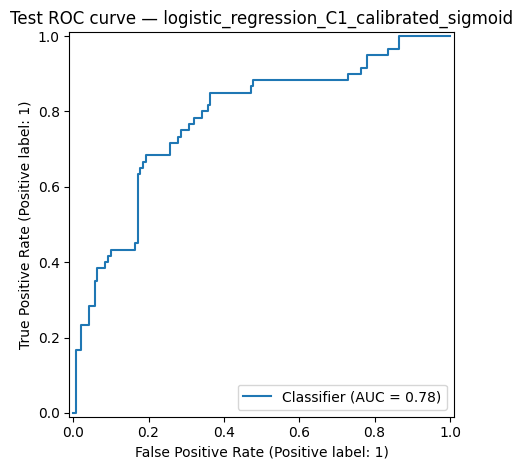

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_score_test)
plt.title(f"Test ROC curve — {final_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roc_curve_final_model_test.png", dpi=150)
plt.show()

## 12. Candidate Model Metadata

This compact metadata file is useful for downstream artefacts and README updates.

In [ ]:
model_metadata = {
    "candidate_model": final_model_name,
    "selected_base_model": selected_model_name,
    "selected_threshold": selected_threshold,
    "threshold_basis": "cost-sensitive analysis on validation set using German Credit asymmetric cost assumption",
    "positive_class": "bad credit risk",
    "cost_false_negative": COST_FALSE_NEGATIVE,
    "cost_false_positive": COST_FALSE_POSITIVE,
    "train_set_size": int(len(y_train)),
    "validation_set_size": int(len(y_val)),
    "test_set_size": int(len(y_test)),
    "test_bad_risk_rate": float(y_test.mean()),
    "test_roc_auc": float(roc_auc_score(y_test, y_score_test)),
    "test_average_precision": float(average_precision_score(y_test, y_score_test)),
    "test_brier_score": float(brier_score_loss(y_test, y_score_test)),
    "selection_reason": selection_reason
}

with open(TABLES_DIR / "model_metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)

model_metadata

{'candidate_model': 'logistic_regression_C1_calibrated_sigmoid',
 'selected_base_model': 'logistic_regression_C1',
 'selected_threshold': 0.16,
 'threshold_basis': 'cost-sensitive analysis on validation set using German Credit asymmetric cost assumption',
 'positive_class': 'bad credit risk',
 'cost_false_negative': 5,
 'cost_false_positive': 1,
 'train_set_size': 600,
 'validation_set_size': 200,
 'test_set_size': 200,
 'test_bad_risk_rate': 0.3,
 'test_roc_auc': 0.7795238095238095,
 'test_average_precision': 0.6122322191698928,
 'test_brier_score': 0.1645090087127678,
 'selection_reason': 'Selected logistic regression because it was within 0.02 ROC AUC of the best validation model and is easier to explain.'}

## 13. Governance Interpretation

The threshold selected in this notebook is a candidate operating threshold, not a deployment decision.

A lower threshold usually catches more bad-risk applicants, but it also flags more good-risk applicants. In governance terms, this affects:

- customer exclusion risk;
- workload for manual review;
- potential subgroup disparities;
- business risk appetite;
- explainability needs for adverse outcomes.

The next notebook will test whether the candidate threshold creates material differences across gender, age group and foreign worker status.

In [ ]:
selected = test_summary[test_summary["threshold_basis"] == "cost_sensitive_selected_on_validation"].iloc[0]
default = test_summary[test_summary["threshold_basis"] == "default_0_50"].iloc[0]

results_text = f"""
# Results to Copy into Governance Artefacts

## Model and Threshold

- Candidate model: `{final_model_name}`
- Selected base model: `{selected_model_name}`
- Positive class: bad credit risk
- Selected threshold: `{selected_threshold:.2f}`
- Threshold basis: cost-sensitive analysis on the validation set using the German Credit asymmetric cost assumption.
- Assumed cost of false negative: {COST_FALSE_NEGATIVE}
- Assumed cost of false positive: {COST_FALSE_POSITIVE}

## Held-Out Test Performance

- ROC AUC: {roc_auc_score(y_test, y_score_test):.3f}
- Average precision: {average_precision_score(y_test, y_score_test):.3f}
- Brier score: {brier_score_loss(y_test, y_score_test):.3f}

## Default Threshold 0.50 on Test Set

- Accuracy: {default['accuracy']:.3f}
- Precision for bad risk: {default['precision_bad_risk']:.3f}
- Recall for bad risk: {default['recall_bad_risk']:.3f}
- False positives: {int(default['false_positives'])}
- False negatives: {int(default['false_negatives'])}
- High-risk flag rate: {default['high_risk_flag_rate']:.3f}
- Total assumed cost: {int(default['total_cost'])}

## Selected Cost-Sensitive Threshold on Test Set

- Accuracy: {selected['accuracy']:.3f}
- Precision for bad risk: {selected['precision_bad_risk']:.3f}
- Recall for bad risk: {selected['recall_bad_risk']:.3f}
- False positives: {int(selected['false_positives'])}
- False negatives: {int(selected['false_negatives'])}
- High-risk flag rate: {selected['high_risk_flag_rate']:.3f}
- Total assumed cost: {int(selected['total_cost'])}

## Governance Interpretation

The selected threshold was chosen on the validation set and evaluated on a separate held-out test set. It reduces expected cost under the stated cost assumption, but it should not be treated as a final deployment decision. It changes the balance between credit risk detection and customer exclusion risk. Before any deployment recommendation, the threshold should be reviewed against subgroup fairness results, explainability evidence, operational workload and human oversight requirements.

## Open Items for Notebook 02

- Check whether the selected threshold creates material differences across gender, age group and foreign worker status.
- Review false positive and false negative rates by subgroup.
- Assess whether the main model drivers are explainable and acceptable for credit risk decision support.
- Document residual Responsible AI risks and required controls.
"""

print(results_text)

with open(TABLES_DIR / "results_to_copy_into_governance_artefacts.md", "w") as f:
    f.write(results_text)


# Results to Copy into Governance Artefacts

## Model and Threshold

- Candidate model: `logistic_regression_C1_calibrated_sigmoid`
- Selected base model: `logistic_regression_C1`
- Positive class: bad credit risk
- Selected threshold: `0.16`
- Threshold basis: cost-sensitive analysis on the validation set using the German Credit asymmetric cost assumption.
- Assumed cost of false negative: 5
- Assumed cost of false positive: 1

## Held-Out Test Performance

- ROC AUC: 0.780
- Average precision: 0.612
- Brier score: 0.165

## Default Threshold 0.50 on Test Set

- Accuracy: 0.750
- Precision for bad risk: 0.619
- Recall for bad risk: 0.433
- False positives: 16
- False negatives: 34
- High-risk flag rate: 0.210
- Total assumed cost: 186

## Selected Cost-Sensitive Threshold on Test Set

- Accuracy: 0.515
- Precision for bad risk: 0.371
- Recall for bad risk: 0.883
- False positives: 90
- False negatives: 7
- High-risk flag rate: 0.715
- Total assumed cost: 125

## Governance Interpreta

## 14. Files Saved

The following outputs are saved for use in the GitHub repository:

- `outputs/tables/split_summary.csv`
- `outputs/tables/model_comparison_validation.csv`
- `outputs/tables/calibration_comparison_validation.csv`
- `outputs/tables/threshold_comparison_validation_all.csv`
- `outputs/tables/governance_model_summary_test.csv`
- `outputs/tables/threshold_comparison_test_selected.csv`
- `outputs/tables/test_predictions_for_fairness.csv`
- `outputs/tables/model_metadata.json`
- `outputs/tables/results_to_copy_into_governance_artefacts.md`
- `outputs/figures/calibration_curve_validation.png`
- `outputs/figures/cost_sensitive_threshold_curve_validation.png`
- `outputs/figures/confusion_matrix_test_threshold_050.png`
- `outputs/figures/confusion_matrix_test_selected_threshold.png`
- `outputs/figures/roc_curve_final_model_test.png`

Next step: use these results to update the README and then proceed to Notebook 02 for fairness, explainability and testing.